# 01 Scalar Autodiff Engine

A from-scratch build log for a tiny scalar autodiff engine.

## Scope
- build a minimal `Value` object
- track scalar operations and local gradients
- run backprop on a toy graph
- validate the engine with a numerical gradient check


In [204]:
%matplotlib inline

from pathlib import Path
import math
import random

import matplotlib.pyplot as plt
import numpy as np

try:
    import torch
    TORCH_AVAILABLE = True
except ImportError:
    torch = None
    TORCH_AVAILABLE = False

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(SEED)

PROJECT_ROOT = Path.cwd()
if not (PROJECT_ROOT / "notebooks").exists():
    PROJECT_ROOT = PROJECT_ROOT.parent

print(f"torch available: {TORCH_AVAILABLE}")
PROJECT_ROOT


torch available: True


PosixPath('/Users/vallari/src/zero-to-research')

## Calculus warm-up

Before building the engine, start with a scalar function and estimate its
slope numerically.


In [205]:
def f(x):
    return 3*x**2 - 4*x + 5

f(3.0)


20.0

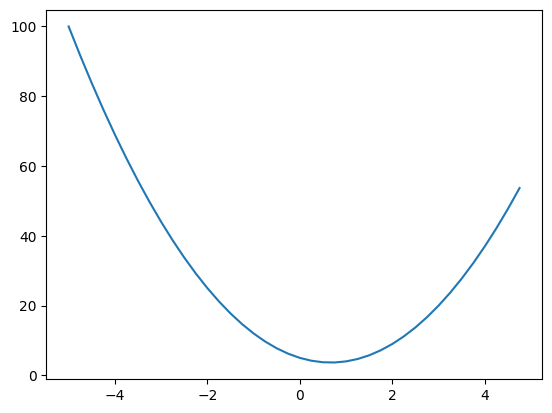

In [206]:
xs = np.arange(-5, 5, 0.25)
ys = f(xs)
plt.plot(xs, ys)


In [207]:
h = 0.000001
x = 2/3
(f(x + h) - f(x)) / h


2.999378523327323e-06

## A slightly more complex expression

Now move from a single scalar function to a small computation built from
multiple inputs.


In [208]:
# let's get more complex
a = 2.0
b = -3.0
c = 10.0
d = a*b + c
print(d)


4.0


In [209]:
h = 0.0001

# inputs
a = 2.0
b = -3.0
c = 10.0

d1 = a*b + c
a += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)


d1 4.0
d2 3.999699999999999
slope -3.000000000010772


In [210]:
# for b

d1 = a*b + c
b += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 3.999699999999999
d2 3.99990001
slope 2.0001000000124947


In [211]:
# for c

d1 = a*b + c
c += h
d2 = a*b + c

print('d1', d1)
print('d2', d2)
print('slope', (d2 - d1) / h)

d1 3.99990001
d2 4.00000001
slope 0.9999999999976694


## Start the `Value` object

Now wrap a scalar in a small Python object. This is the first step toward
tracking a computation graph instead of only passing raw floats around.


In [212]:
class Value:
    def __init__(self, data, _children=(), _op='', label= ''):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self):
        return f"Value(data={self.data})"

    def __add__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data + other.data, (self, other), '+')

        def _backward():
            self.grad += 1.0 * out.grad
            other.grad += 1.0 * out.grad
        out._backward = _backward
        return out

    def __mul__(self, other):
        other = other if isinstance(other, Value) else Value(other)
        out = Value(self.data * other.data, (self, other), '*')

        def _backward():
            self.grad += other.data * out.grad
            other.grad += self.data * out.grad
        out._backward = _backward
        return out

    def __pow__(self, other):
        assert isinstance(other, (int, float))
        out = Value(self.data ** other, (self,), f'**{other}')

        def _backward():
            self.grad += other * (self.data ** (other - 1)) * out.grad
        out._backward = _backward
        return out

    def __neg__(self):
        return self * -1

    def __sub__(self, other):
        return self + (-other)

    def __rsub__(self, other):
        return other + (-self)

    def __radd__(self, other):
        return self + other

    def __rmul__(self, other):
        return self * other

    def tanh(self):
        x = self.data
        t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
        out = Value(t, (self, ), 'tanh')
        def _backward():
          self.grad += (1 - t**2) * out.grad
        out._backward = _backward
        
        return out

    def backward(self):
        topo = []
        visited = set()
        def build_topo(v):
          if v not in visited:
            visited.add(v)
            for child in v._prev:
              build_topo(child)
            topo.append(v)
        build_topo(self)
        
        self.grad = 1.0
        for node in reversed(topo):
          node._backward()


## Why gradients use `+=`

A node can affect the final output through more than one path. During backprop,
each path sends one local gradient contribution back to that node.

Using `+=` accumulates all of those contributions. Using `=` would overwrite the
earlier contribution with the later one.

Example:

```python
a = Value(2.0)
b = a + a
```

Here `a` is used twice. Each `+` edge contributes `1`, so the correct gradient is
`db/da = 1 + 1 = 2`. With assignment, one contribution would overwrite the
other and incorrectly leave `a.grad = 1`.


In [213]:
a = Value(2.0)
b = Value(-1.0)
a,b

(Value(data=2.0), Value(data=-1.0))

In [214]:
a+b

Value(data=1.0)

In [215]:
a*b

Value(data=-2.0)

In [216]:
a = Value(2.0, label='a')
b = Value(-3.0, label = 'b')
c = Value(10.0, label = 'c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
print(d)

Value(data=4.0)


In [217]:
d._op

'+'

In [218]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f}" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

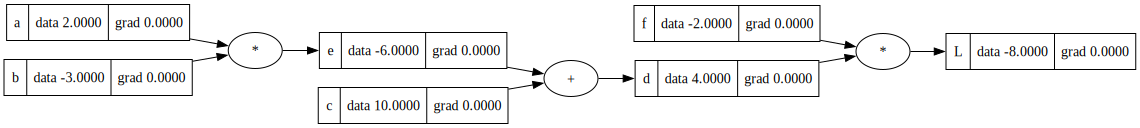

In [219]:
draw_dot(L)

In [220]:
L.grad = 1.0

In [221]:
# L = d * f
# dL/dd = f

d.grad =  -2.0 #f
f.grad = 4.0 #d

In [222]:
# dL/ dc

# dd / dc 
# d = (e + c)
# dd/ dc = 1.0
# dd / de = 1.0

# we know local derivative of dd/ dc but we want wrt L (dL/ dc), we know the dL/dd = -2

# WANT:
# dL/ dc

# KNOW: dL/dd , dd / dc 

# so dL/ dc = dL/dd * dd/dc  = -2 * 1 = -2
# similarly dL/ de = -2

# so what plus does is literally just route the derivative of d to both c and e

# L = d * f = (e + c) * f ; c = L/f - e

c.grad = -2
e.grad = -2


In [223]:
# what is dL/da = ?
# dL/de = -2
# de/da = ?
# e = a * b; de/da = b = -3
# dL/da = dL/de * de/da = -2 * -3 = 6
# similarly, dL/db = -2 * a = -2 * 2 = -4

a.grad = 6
b.grad = -4

In [224]:
def lol():
  
  h = 0.001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  a.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)
  
lol()

6.000000000000227


In [225]:
def lol():
  
  h = 0.001
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L1 = L.data
  
  a = Value(2.0, label='a')
  b = Value(-3.0, label='b')
  b.data += h
  c = Value(10.0, label='c')
  e = a*b; e.label = 'e'
  d = e + c; d.label = 'd'
  f = Value(-2.0, label='f')
  L = d * f; L.label = 'L'
  L2 = L.data
  
  print((L2 - L1)/h)
  
lol()

-3.9999999999995595


In [226]:
# forward propogation, increase by step amount 

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-7.286496


In [227]:
# forward propogation, increase by step amount 

a.data += 0.01 * a.grad
b.data += 0.01 * b.grad
c.data += 0.01 * c.grad
f.data += 0.01 * f.grad

e = a * b
d = e + c
L = d * f

print(L.data)

-6.586368000000001


## Neural Network

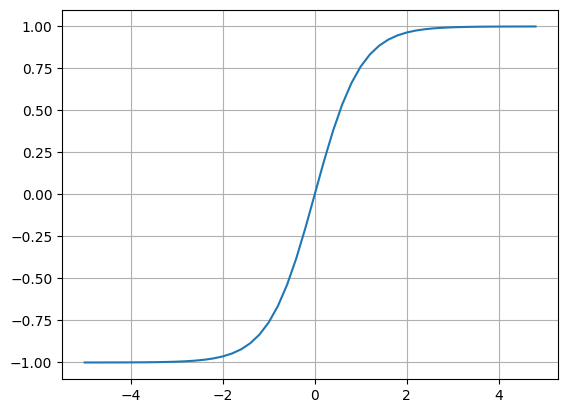

In [228]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [229]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'

n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'


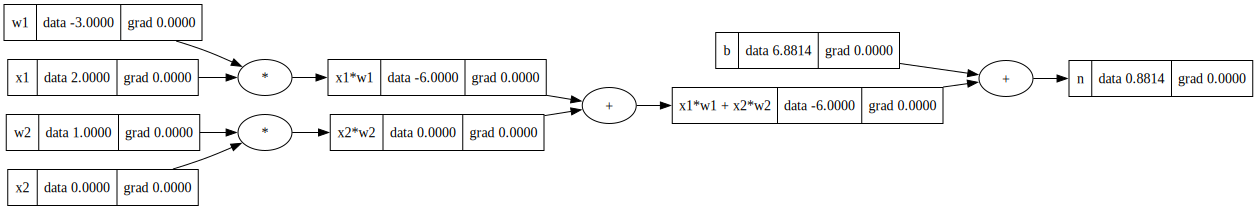

In [230]:
draw_dot(n)

In [231]:
# activation
o =  n.tanh(); o.label = 'o'

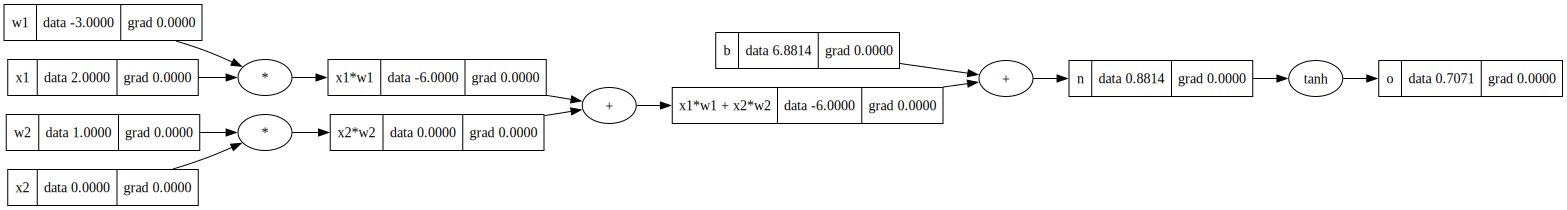

In [232]:
draw_dot(o)

In [233]:
o.grad = 1.0

## Research delta

Implement `numerical_grad_check(root, eps=1e-6)` and compare analytical
versus numerical gradients on several random scalar graphs.

This is the first real claim in the notebook: the autodiff engine should be
validated, not trusted.


In [234]:
# do/dn = ?
# o = tanh(n)
# do/dn = 1 - tanh(n)**2 = 1 - o**2
1 - o.data**2

0.4999999999999999

In [235]:
n.grad = 0.5

In [236]:
# due to plus operator 
x1w1x2w2.grad = 0.5
b.grad = 0.5

In [237]:
# plus operator again
x1w1.grad = 0.5
x2w2.grad = 0.5

In [238]:
# x1.grad = w1.data * x1w1.grad
# w1.grad = x1.data * x1w1.grad
# x2.grad = w2.data * x2w2.grad
# w2.grad = x2.data * x2w2.grad

In [239]:
#do/dx2 = w2 * do/x2w2 = w2 * 0.5 = 0.5 
x2.grad = 0.5
w2.grad = 0.0

In [240]:
x1.grad = 0.5 * -3.0
w1.grad = 0.5 * 2

## Alternative using backward

In [241]:
o.grad = 1

In [242]:
o._backward()

In [243]:
n._backward()

In [244]:
b._backward()

In [245]:
x1w1x2w2._backward()

In [246]:
x2w2._backward()
x1w1._backward()

In [247]:
o.backward()

# PyTorch

In [248]:
import torch
x1 = torch.Tensor([2.0]).double()                ; x1.requires_grad = True
x2 = torch.Tensor([0.0]).double()                ; x2.requires_grad = True
w1 = torch.Tensor([-3.0]).double()               ; w1.requires_grad = True
w2 = torch.Tensor([1.0]).double()                ; w2.requires_grad = True
b = torch.Tensor([6.8813735870195432]).double()  ; b.requires_grad = True
n = x1*w1 + x2*w2 + b
o = torch.tanh(n)

print(o.data.item())
o.backward()

print('---')
print('x2', x2.grad.item())
print('w2', w2.grad.item())
print('x1', x1.grad.item())
print('w1', w1.grad.item())

0.7071066904050358
---
x2 0.5000001283844369
w2 0.0
x1 -1.5000003851533106
w1 1.0000002567688737


## Neuron API

Now wrap the scalar engine into small neural-network building blocks. A neuron is a weighted sum plus bias, followed by a nonlinearity.


In [249]:
class Neuron:
  
  def __init__(self, nin):
    self.w = [Value(random.uniform(-1,1)) for _ in range(nin)]
    self.b = Value(random.uniform(-1,1))
  
  def __call__(self, x):
    # w * x + b
    act = sum((wi*xi for wi, xi in zip(self.w, x)), self.b)
    out = act.tanh()
    return out
  
  def parameters(self):
    return self.w + [self.b]

class Layer:
  
  def __init__(self, nin, nout):
    self.neurons = [Neuron(nin) for _ in range(nout)]
  
  def __call__(self, x):
    outs = [n(x) for n in self.neurons]
    return outs[0] if len(outs) == 1 else outs
  
  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:
  
  def __init__(self, nin, nouts):
    sz = [nin] + nouts
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(nouts))]
  
  def __call__(self, x):
    for layer in self.layers:
      x = layer(x)
    return x
  
  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]

In [250]:
# x = [2.0, 3.0] 
# n = Neuron(2)
# n(x)
x = [
    Value(2.0, label='x0'),
    Value(3.0, label='x1'),
    Value(-1.0, label='x2'),
]
n = MLP(3, [4, 4, 1])
out = n(x)
out.label = 'out'
out

Value(data=0.6994093620224068)

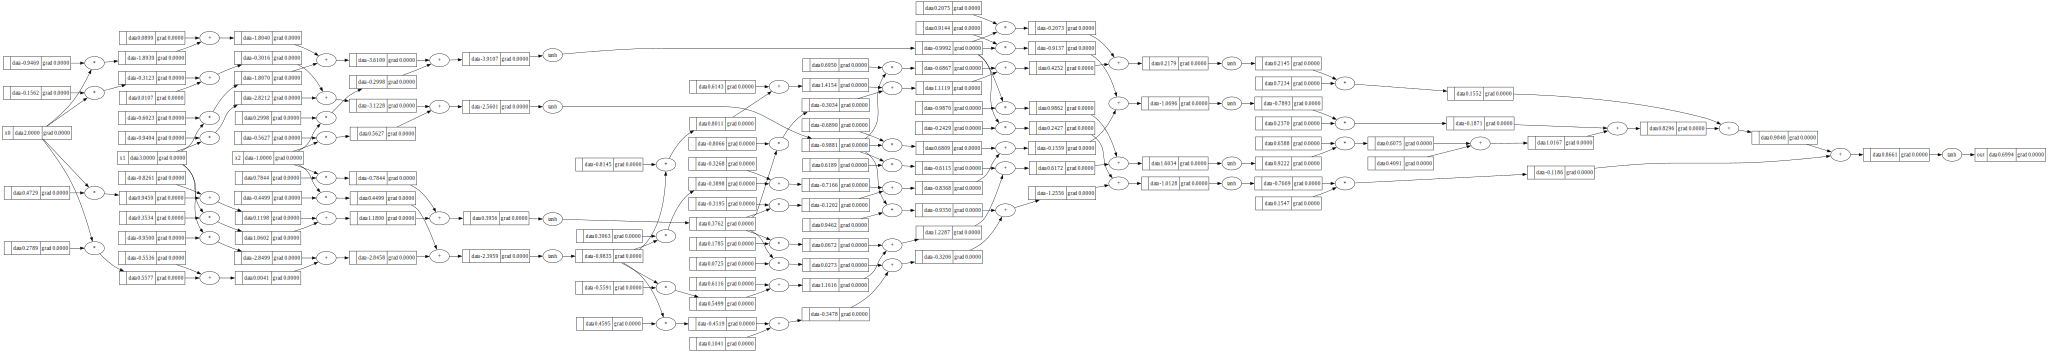

In [251]:
draw_dot(out)

In [257]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
ypred = [n(x) for x in xs]
ypred

[Value(data=0.6994093620224068),
 Value(data=0.5026295816615511),
 Value(data=0.6931545900944501),
 Value(data=0.8755224728708613)]

In [ ]:
[(yout-ygt)**2 for ygt, yout in zip(ys,ypred)]

In [252]:
# TODO
# 1. Implement Value
# 2. Build a toy computation graph
# 3. Call backward()
# 4. Add a finite-difference gradient check
# 5. Summarize mismatches, if any


## Findings

- Baseline result:
- Delta result:
- Takeaway:
